In [134]:
# Import libraries for data handling, plotting, and missing-value imputation
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [113]:
# Load the Titanic dataset from seaborn
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [114]:
# Check the percentage of missing values in each column
# print(df.isnull().sum())
print("======>")
missing_percentage = df.isnull().mean() * 100
print(missing_percentage.sort_values(ascending=False))

======>
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64


## 1. Analyze Missingness

Before filling missing values, check whether the missing values look random or related to other columns.

In [115]:
# Create a flag: 1 means age is missing, 0 means age is present
df["age_missing"] = df["age"].isnull().astype(int)
# Compare both groups to see if missing age is related to survival, fare, class, or adult_male
df.groupby("age_missing")[["survived", "fare", "pclass", "adult_male"]].mean()

,survived,fare,pclass,adult_male
age_missing,,,,
0,0.406162,34.694514,2.236695,0.578431
1,0.293785,22.158567,2.598870,0.700565


**Interpretation:** If rows with missing age have different survival rate, fare, class, or adult_male values, the missingness is not completely random.

In that case, a missing indicator column can help the model.

## 2. Methods to Handle Missing Values

### 1. Drop Rows

In [116]:
# Use this when only a few rows have missing values
# embarked and embark_town have only 2 missing values
df_drop_rows = df.dropna(
    subset=["embarked", "embark_town"]
)  # subset drops rows only when these selected columns are missing
print("Original Shape", df.shape)
print("Shape after dropping rows", df_drop_rows.shape)

Original Shape (891, 16)
Shape after dropping rows (889, 16)


### 2. Drop Columns

In [117]:
# Use this when a column has too many missing values, usually more than 70%
# deck has about 77% missing values, so dropping it can be reasonable
df_drop_col = df.drop(columns=["deck"])
df_drop_col.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_missing
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0


In [118]:
# If deck may still be useful, keep it and mark missing values as a separate category
# deck is categorical, so add "missing" as a valid category before filling null values
if "missing" not in df["deck"].cat.categories:
    df["deck"] = df["deck"].cat.add_categories("missing")

df["deck"] = df["deck"].fillna("missing")

print("Number of missing values in deck:", df["deck"].isnull().sum())

Number of missing values in deck: 0


### 3. Mean Imputation

<Axes: xlabel='age', ylabel='Density'>

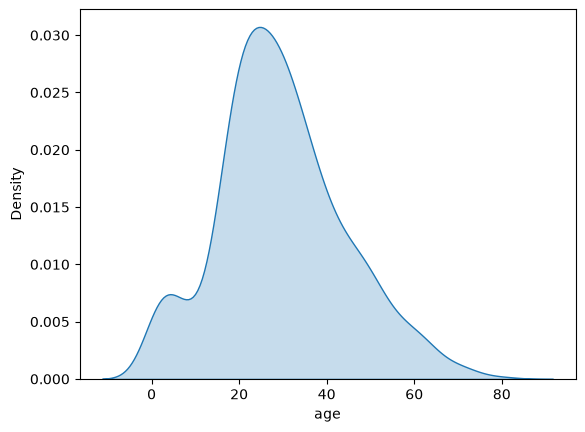

In [119]:
# Check the age distribution before imputing missing values
sns.kdeplot(df["age"], fill=True)

In [120]:
df_mean = df.copy()
# Fill missing age values with the mean age
age_mean = df["age"].mean()
df_mean["age_mean_imputed"] = df_mean["age"].fillna(age_mean)
df_mean[["age", "age_mean_imputed"]].tail()

,age,age_mean_imputed
886,27.0,27.000000
887,19.0,19.000000
888,NaN,29.699118
889,26.0,26.000000
890,32.0,32.000000


<Axes: xlabel='age_mean_imputed', ylabel='Density'>

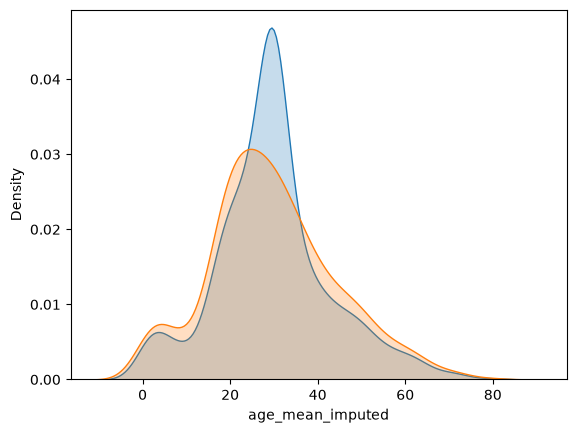

In [121]:
sns.kdeplot(df_mean["age_mean_imputed"], fill=True)
sns.kdeplot(
    df["age"],
    fill=True,
)
# Mean imputation can reduce variance because many missing values get the same number
# It works best when the distribution is close to normal and only a few values are missing

### 4. Median Imputation

<Axes: xlabel='age_median_imputed', ylabel='Density'>

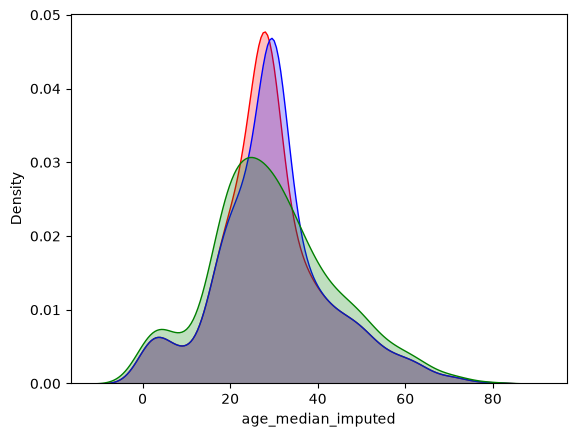

In [122]:
# Use median imputation for numerical data with outliers or skewed distribution
df_median = df.copy()
# Fill missing age values with the median age
age_median = df_median["age"].median()
df_median["age_median_imputed"] = df_median["age"].fillna(age_median)
sns.kdeplot(
    df_median["age_median_imputed"], fill=True, label="Median Imputation", color="red"
)

sns.kdeplot(
    df_mean["age_mean_imputed"], fill=True, label="Mean Imputation", color="blue"
)

sns.kdeplot(df["age"], fill=True, label="Original Age", color="green")

### 5. Mode Imputation

In [123]:
# Use mode imputation for categorical columns
# It works well when one category clearly appears most often
# If categories are evenly distributed, mode imputation can add bias toward one category
df_mode = df.copy()
embarked_mode = df_mode["embarked"].mode()[0]
df_mode["embarked"] = df_mode["embarked"].fillna(embarked_mode)

### 6. Missing as a New Category

In [124]:
# Instead of dropping rows or using mode, keep missing values as their own category
df_missing = df.copy()
# embark_town is a string-like column, so we can directly fill null values with "missing"
df_missing["embark_town"] = df_missing["embark_town"].fillna("missing")
df_missing["embark_town"].isnull().sum()  # 0 means all missing values were replaced
# Sometimes missing itself has meaning, such as an optional or intentionally skipped field
# Keeping it as a category may help the model learn that pattern

np.int64(0)

### 7. Missing Indicator Column

In [125]:
# This is useful for numerical columns when missingness may carry information
df_indicator = df.copy()
df_indicator["age_missing"] = df_indicator["age"].isnull().astype(int)
df_indicator["age"] = df_indicator["age"].fillna(df_indicator["age"].median())

df_indicator[["age", "age_missing"]].tail()
# Benefit: the model gets two signals
# 1. The imputed age value
# 2. Whether age was originally missing
# This is useful for MAR or MNAR cases

,age,age_missing
886,27.0,0
887,19.0,0
888,28.0,1
889,26.0,0
890,32.0,0


### 8. Random Sample Imputation

<Axes: xlabel='age', ylabel='Density'>

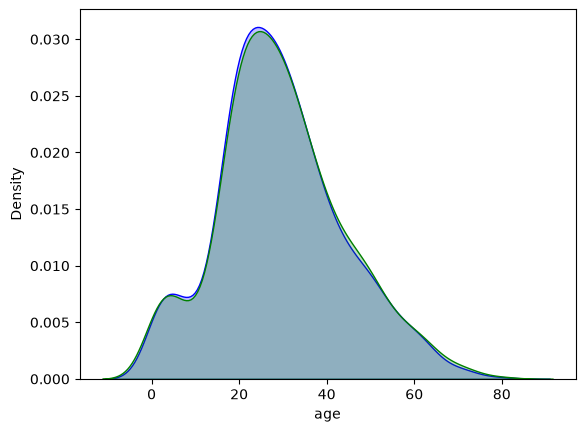

In [126]:
# This preserves the original distribution better than mean or median imputation
df_random = df.copy()
missing_count = df_random["age"].isnull().sum()
random_samples = df_random["age"].dropna().sample(missing_count, random_state=42)
# Match the sampled values to the exact rows where age is missing
random_samples.index = df_random[df_random["age"].isnull()].index
df_random["age"] = df_random["age"].fillna(random_samples)


sns.kdeplot(df_random["age"], fill=True, label="Random Imputation", color="blue")

sns.kdeplot(df["age"], fill=True, label="Original Age", color="green")
# The filled column keeps a distribution close to the original age distribution

### 9. KNN Imputation

The idea is simple:

- If one passenger's age is missing, find similar passengers.
- Use the nearby passengers' values to estimate the missing age.
- This uses row similarity instead of one fixed value like mean or median.

In [ ]:
# Select numeric columns that can help KNN find similar passengers
df_knn = df[["age", "fare", "pclass", "survived", "parch"]].copy()
# KNNImputer only fills missing values and leaves existing values unchanged
inputer = KNNImputer(
    n_neighbors=5
)  # Use the 5 nearest neighbors to estimate each missing value

# fit_transform returns a NumPy array, so convert it back to a DataFrame
df_knn_imputed = pd.DataFrame(inputer.fit_transform(df_knn), columns=df_knn.columns)

age         0
fare        0
pclass      0
survived    0
parch       0
dtype: int64

In [ ]:
# KNN uses distance, so features with larger scales can dominate the result
# Standardize first, impute on the scaled data, then convert values back to the original scale
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)

# standardize dataset
scaled_df = scaler.fit_transform(df_knn)
# imputed dataset based on KNN with 5 neighbors
imputed_df = imputer.fit_transform(scaled_df)
inversed_scaled_df = scaler.inverse_transform(imputed_df)

df_knn_imputed = pd.DataFrame(
    inversed_scaled_df, columns=df_knn.columns, index=df_knn.index
)
df_knn_imputed.isnull().sum()

age         0
fare        0
pclass      0
survived    0
parch       0
dtype: int64

### 10. Forward Fill and Backward Fill

In [151]:
# Forward fill and backward fill are mainly used for time series data
# Create a small sample time series dataset
dates = pd.date_range(start="2023-01-01", end="2023-01-10", freq="D")
ts = pd.DataFrame(
    {"date": dates, "temp": [30, 10, np.nan, 40, 50, 60, 70, np.nan, 90, np.nan]}
)
ts

,date,temp
0,2023-01-01,30.0
1,2023-01-02,10.0
2,2023-01-03,NaN
3,2023-01-04,40.0
4,2023-01-05,50.0
5,2023-01-06,60.0
6,2023-01-07,70.0
7,2023-01-08,NaN
8,2023-01-09,90.0
9,2023-01-10,NaN


In [154]:
# Forward fill uses the previous known value
ts["temp_ffill"] = ts["temp"].ffill()
# Backward fill uses the next known value
ts["temp_bfill"] = ts["temp"].bfill()
ts

,date,temp,temp_ffill,temp_bfill
0,2023-01-01,30.0,30.0,30.0
1,2023-01-02,10.0,10.0,10.0
2,2023-01-03,NaN,10.0,40.0
3,2023-01-04,40.0,40.0,40.0
4,2023-01-05,50.0,50.0,50.0
5,2023-01-06,60.0,60.0,60.0
6,2023-01-07,70.0,70.0,70.0
7,2023-01-08,NaN,70.0,90.0
8,2023-01-09,90.0,90.0,90.0
9,2023-01-10,NaN,90.0,NaN
